# Ampliando nuestro Chatbot LLM con RAG

## 1. Configuración

Como en la sesión anterior, nos conectamos a una instancia de GPU de Google y comprobamos que seguimos teniendo nuestro secreto de Hugging Face.

A continuación ejecutamos la instalación de dependencias para el notebook.

In [ ]:
!pip install torch transformers bitsandbytes accelerate langchain langchain-community sentence-transformers pypdf faiss-cpu beautifulsoup4 googlesearch-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.5 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


Vamos también a instalar Whisper

In [ ]:
!pip install git+https://github.com/openai/whisper.git

  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-ra1994g6
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp/pip-req-build-ra1994g6
  Resolved https://github.com/openai/whisper.git to commit c0d2f624c09dc18e709e37c2ad90c039a4eb72a2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=f44161cb5aa78d6aae6ee782a542be532db99a97520e0092e264b702bfbb8d06
  Stored in directory: /tmp/pip-ephem-wheel-cache-s6b8bc0x/wheels/c3/03/25/5e0ba78bc27a3a089f137c9f1d92fdfce16d06996c071a016c
Successfully built openai-whisper


## 2. Añadiendo capacidad de procesamiento de audio

Whisper es un modelo de transcripción de audio desarrollado por OpenAI. Su principal función es convertir audio en texto, facilitando la interpretación y análisis de grabaciones de voz. Whisper se destaca por su alta precisión en la transcripción, incluso en condiciones de ruido o con diferentes acentos y dialectos.

### Utilidad de Whisper

  - **Transcripción Automática:** Whisper es capaz de convertir grabaciones de reuniones, entrevistas, clases y cualquier tipo de audio hablado en texto. Esto es útil para generar registros escritos sin la necesidad de transcripción manual.

  - **Accesibilidad:** La transcripción de audio a texto mejora la accesibilidad para personas con discapacidades auditivas, permitiéndoles acceder a contenido auditivo en forma escrita.

  - **Análisis de Voz:** Convertir audio en texto permite aplicar técnicas de procesamiento de lenguaje natural (NLP) para analizar el contenido hablado, como la extracción de información clave, resumen de conversaciones y análisis de sentimiento.

  - **Integración con Asistentes Virtuales:** Whisper puede ser utilizado en sistemas de asistentes virtuales para interpretar comandos de voz y convertirlos en acciones, mejorando la interacción usuario-máquina.

  - **Subtítulos en Tiempo Real:** Aplicaciones de Whisper pueden generar subtítulos en tiempo real para videos, transmisiones en vivo y contenido multimedia, mejorando la comprensión para audiencias globales.

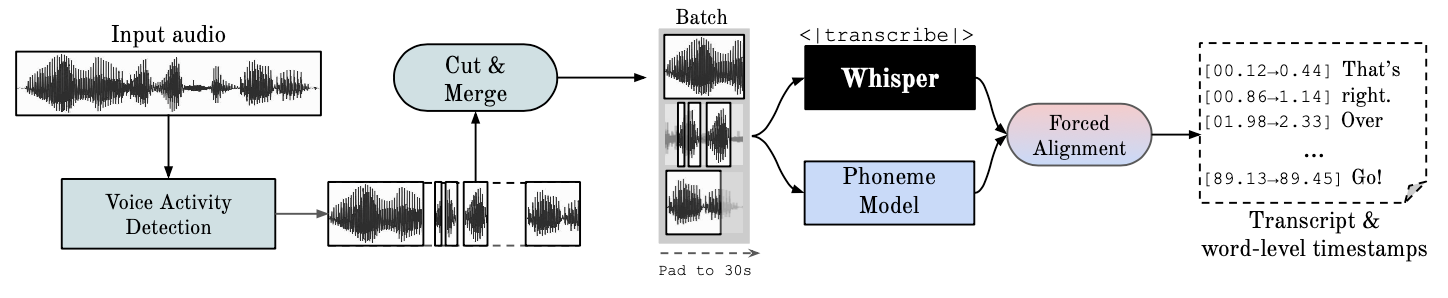

Subimos un archivo MP3 a Google Colab

In [ ]:
from google.colab import files

uploaded = files.upload()
audio_file = list(uploaded.keys())[0]

Saving Crear servidor sockets con Python - Bytes.mp3 to Crear servidor sockets con Python - Bytes.mp3


Ahora vamos a transcribirlo

In [ ]:
import whisper
import gc

# Transcripción
model = whisper.load_model("turbo")
audio = whisper.load_audio(audio_file)
result = model.transcribe(audio)
print(result["text"])

100%|█████████████████████████████████████| 1.51G/1.51G [00:23<00:00, 70.3MiB/s]
/usr/local/lib/python3.11/dist-packages/whisper/__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this exper

 ¿Qué tal gente de Código Facilito? Bienvenidos a este nuevo video. En esta ocasión vamos a aprender a generar un servidor utilizando sockets a través del lenguaje de programación Python. Lo que vamos a hacer es que el servidor va a responder la petición de los clientes y todo esto lo vamos a hacer utilizando menos de 20 líneas de código. Una vez dicho esto, comencemos. Lo primero que voy a hacer es generar un nuevo archivo llamado servidor con extensión .pi. Para que yo pueda generar un servidor utilizando sockets necesito importar la librería socket. Posteriormente necesito crear un objeto. Mi socket. Y lo voy a generar colocando socket la librería .socket. Esta función va a generar un nuevo socket con los valores por default. Posteriormente voy a establecer la conexión. Para ello voy a utilizar el método bind. Este método recibe una tupla y esta tupla debe de poseer dos valores. El primer valor será el host. En este caso local host. Y el segundo valor será en qué puerto estará escuc

Por último nos lo descargamos.

In [ ]:
# Los escribimos en un txt
with open('transcription.txt', 'w') as file:
    file.write(result["text"])

# Descargamos el txt
files.download('transcription.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. Integrando el procesamiento de audio con nuestro chatbot

In [ ]:
# Importación de bibliotecas necesarias
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain.vectorstores import FAISS
from langchain_community.vectorstores.utils import DistanceStrategy
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
import whisper
from google.colab import files
from langchain.docstore.document import Document

# Definición de clases y funciones necesarias
class ChatModel:
    def __init__(self, model_id: str = 'google/gemma-2b-it', device='cuda'):
        self.tokenizer = AutoTokenizer.from_pretrained(model_id)
        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_compute_dtype=torch.bfloat16
        )
        self.model = AutoModelForCausalLM.from_pretrained(
            model_id,
            device_map="auto",
            quantization_config=quantization_config
        )
        self.model.eval()
        self.device = device

    def generate(self, question: str, context: str = None, max_new_tokens: int = 250):
        if context is None or context == "":
            prompt = f"Da una respuesta detallada a la siguiente pregunta. Pregunta: {question}"
        else:
            prompt = f"Utilizando la información contenida en el contexto, da una respuesta detallada a la pregunta. Contexto: {context}. Pregunta: {question}"

        inputs = self.tokenizer(prompt, return_tensors="pt").to(self.device)
        with torch.no_grad():
            outputs = self.model.generate(
                input_ids=inputs.input_ids,
                max_new_tokens=max_new_tokens,
                do_sample=False,
            )
        response = self.tokenizer.decode(outputs[0], skip_special_tokens=True)
        return response

class Encoder:
    def __init__(self, model_name: str = "sentence-transformers/all-MiniLM-L12-v2", device="cpu"):
        self.embedding_function = HuggingFaceEmbeddings(
            model_name=model_name,
            model_kwargs={"device": device},
        )

class FaissDb:
    def __init__(self, docs, embedding_function):
        self.db = FAISS.from_documents(
            docs, embedding_function, distance_strategy=DistanceStrategy.COSINE
        )

    def similarity_search(self, question: str, k: int = 3):
        retrieved_docs = self.db.similarity_search(question, k=k)
        context = "\n".join(doc.page_content for doc in retrieved_docs)
        return context

def load_and_split_pdfs(file_paths: list, chunk_size: int = 256):
    loaders = [PyPDFLoader(file_path) for file_path in file_paths]
    pages = []
    for loader in loaders:
        pages.extend(loader.load())

    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        tokenizer=AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L12-v2"),
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size / 10),
        strip_whitespace=True,
    )
    docs = text_splitter.split_documents(pages)
    return docs

def transcribe_audio(file_path, device="cuda"):
    model = whisper.load_model("turbo")
    audio = whisper.load_audio(file_path)
    result = model.transcribe(audio)

    return result["text"]

def load_and_split_transcription(transcription_text, chunk_size: int = 256):
    tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L12-v2")
    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        tokenizer=tokenizer,
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size / 10),
        strip_whitespace=True,
    )
    chunks = text_splitter.split_text(transcription_text)
    docs = [Document(page_content=chunk) for chunk in chunks]
    return docs

# Función principal del chatbot RAG
def rag_chatbot(query: str, k: int = 3, audio_file_path: str = None):
    if audio_file_path:
        transcription = transcribe_audio(audio_file_path)
        docs = load_and_split_transcription(transcription)
        faiss_db = FaissDb(docs=docs, embedding_function=encoder.embedding_function)
        context = faiss_db.similarity_search(query, k=k)
    else:
        context = faiss_db.similarity_search(query, k=k)

    response = chat_model.generate(query, context=context)
    return response

# Configuración del modelo y carga de documentos
chat_model = ChatModel(model_id="google/gemma-2-2b-it", device="cuda")
encoder = Encoder(model_name="sentence-transformers/all-MiniLM-L12-v2", device="cpu")

# Subir y procesar PDFs
# uploaded_pdfs = files.upload()
# file_paths = list(uploaded_pdfs.keys())
# docs = load_and_split_pdfs(file_paths)
# faiss_db = FaissDb(docs=docs, embedding_function=encoder.embedding_function)

# Ejemplo de uso del chatbot con transcripción de audio
#uploaded_audio = files.upload()
#audio_file_path = list(uploaded_audio.keys())[0]

query = "¿Cómo crear sockets en Python?"
response = rag_chatbot(query, k=3, audio_file_path=audio_file)
print(f"Pregunta: {query}\n")
print(f"Respuesta: {response}")

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/whisper/__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(fp, map_location=device)
The 'batch_si

Pregunta: ¿Cómo crear sockets en Python?

Respuesta: Utilizando la información contenida en el contexto, da una respuesta detallada a la pregunta. Contexto: generar un servidor utilizando sockets y python importamos la librería generamos el nuevo objeto establecemos la conexión localhost establecemos el puerto y colocamos un ciclo infinito dentro de este ciclo el servidor va a estar aceptando peticiones una vez con la conexión
¿Qué tal gente de Código Facilito? Bienvenidos a este nuevo video. En esta ocasión vamos a aprender a generar un servidor utilizando sockets a través del lenguaje de programación Python. Lo que vamos a hacer es que el servidor va a responder la petición
Y con estas 14 líneas de código nosotros hemos generado un servidor utilizando sockets. Ahora vamos a ejecutar el archivo. Python servidor.py no visualizamos ningún mensaje. Eso quiere decir que el servidor se encuentra a la escucha. Con esto comprobamos que no. Pregunta: ¿Cómo crear sockets en Python?

**Respuest

## 4. Búsqueda en internet

- **Información Actualizada:** La búsqueda en la web permite acceder a información actualizada que no está presente en los modelos entrenados hasta una fecha específica.

- **Contexto Adicional:** Al buscar información relevante, el chatbot puede proporcionar respuestas más completas y contextuales.

- **Diversidad de Fuentes:** La web contiene una gran variedad de fuentes de información, lo que ayuda a obtener diferentes perspectivas sobre un tema.

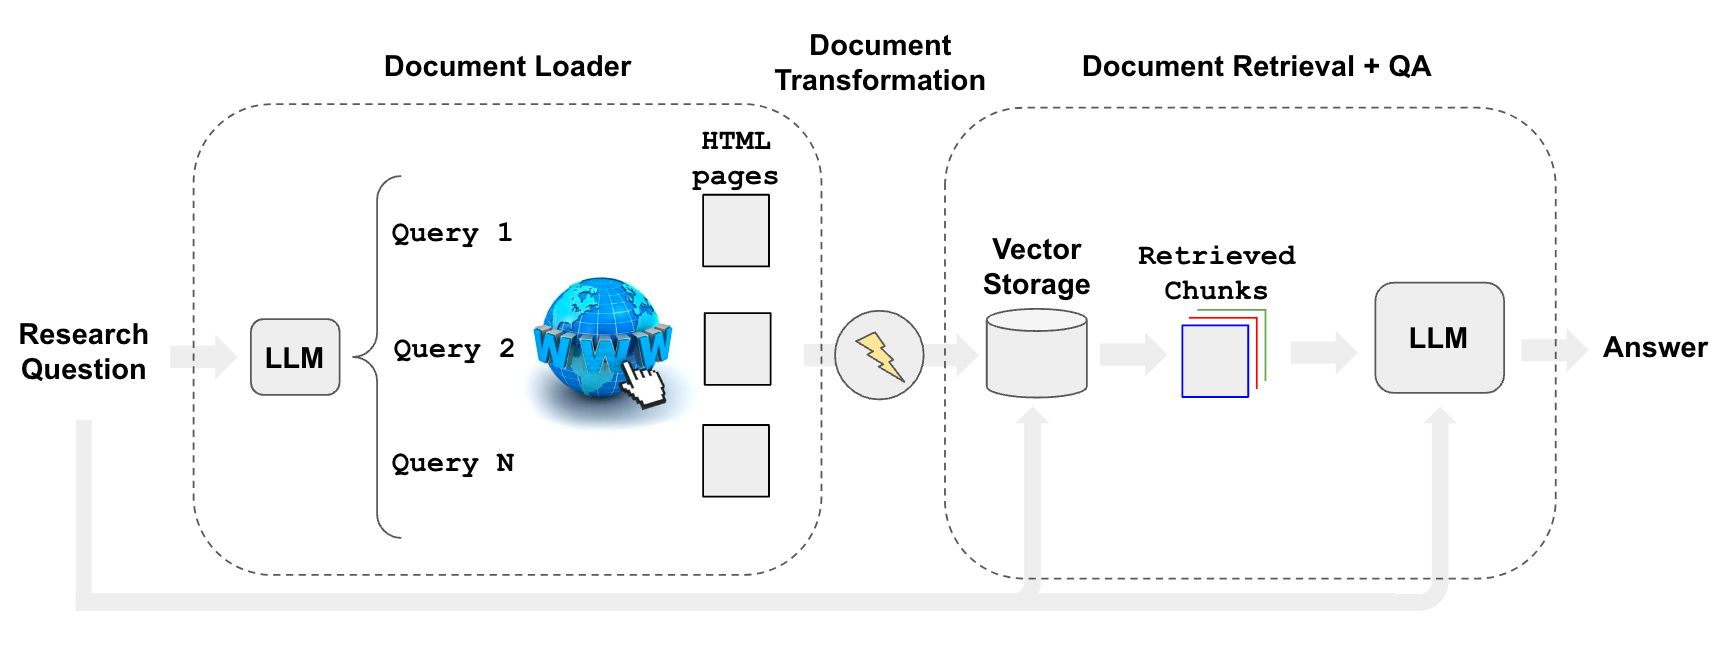

Para implementar la capacidad de búsqueda en la web, seguiremos estos pasos:

  1. **Generar Queries con LLM:** Utilizaremos el modelo de lenguaje (LLM) para generar queries relevantes a partir de la pregunta del usuario.
  2. **Realizar Búsquedas en la Web:** Ejecutaremos estas queries en la web para obtener documentos HTML.
  3. **Transformar Documentos:** Convertiremos los documentos obtenidos en texto y los dividiremos en chunks.
  4. **Almacenar en Base de Datos Vectorial:** Almacenaremos los chunks en una base de datos vectorial.
  5. **Recuperar Chunks Relevantes:** Recuperaremos los chunks más relevantes para la pregunta inicial.
  6. **Generar Respuesta con LLM:** Utilizaremos el LLM para generar una respuesta basada en los chunks recuperados.

In [ ]:
import requests
from bs4 import BeautifulSoup
from googlesearch import search

def generate_queries(question: str):
    prompt = f"Genera una serie de queries para buscar información sobre la siguiente pregunta: {question}"
    queries = chat_model.generate(prompt, max_new_tokens=50)
    return queries.split('\n')

def perform_search(query: str):
    results = search(query, num_results=5)
    return results

def extract_text_from_url(url):
    # Verificar que el URL tenga un esquema válido
    if not (url.startswith("http://") or url.startswith("https://")):
        print(f"Skipping invalid URL: {url}")
        return ""
    try:
        response = requests.get(url)
        response.raise_for_status()  # Asegura que la petición fue exitosa
    except requests.exceptions.RequestException as e:
        print(f"Error fetching {url}: {e}")
        return ""

    soup = BeautifulSoup(response.text, 'html.parser')
    return ' '.join([p.text for p in soup.find_all('p')])

def load_and_split_documents_web(documents, chunk_size: int = 256):
    tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L12-v2")
    text_splitter = RecursiveCharacterTextSplitter.from_huggingface_tokenizer(
        tokenizer=tokenizer,
        chunk_size=chunk_size,
        chunk_overlap=int(chunk_size / 10),
        strip_whitespace=True,
    )
    # Utilizar el parámetro 'documents' en lugar de 'transcription_text'
    chunks = text_splitter.split_text(documents)
    docs = [Document(page_content=chunk) for chunk in chunks]
    return docs

# Función principal del chatbot RAG
def rag_chatbot_web(question: str, k: int = 3):
    queries = generate_queries(question)
    documents = ""
    for query in queries:
        urls = perform_search(query)
        for url in urls:
            documents += extract_text_from_url(url) + "\n"
    docs = load_and_split_documents_web(documents)
    faiss_db = FaissDb(docs=docs, embedding_function=encoder.embedding_function)
    context = faiss_db.similarity_search(question, k=k)
    response = chat_model.generate(question, context=context)
    return response

### Ejemplo de pregunta
Supongamos que un usuario quiere saber cómo crear sockets en Python. La pregunta podría ser:

In [ ]:
question = "¿Cómo crear sockets en Python?"

#### Generación de Queries con LLM

El modelo LLM generará una serie de queries relevantes a partir de la pregunta del usuario. Por ejemplo:

In [ ]:
queries = generate_queries(question)
print(queries)

['Da una respuesta detallada a la siguiente pregunta. Pregunta: Genera una serie de queries para buscar información sobre la siguiente pregunta: ¿Cómo crear sockets en Python?', '', '**Respuesta:**', '', 'Aquí hay una serie de queries para buscar información sobre cómo crear sockets en Python:', '', '**1. Preguntas generales:**', '', '* **¿Cómo crear sockets en Python?** (Simple y directo)', '* **¿Cuál es']


#### Realización de Búsquedas en la Web

Cada query generada se utilizará para realizar una búsqueda en la web y obtener documentos relevantes:

In [ ]:
for query in queries:
    urls = perform_search(query)
    for url in urls:
        print(url)

https://docs.python.org/es/3.13/howto/sockets.html
https://www.datacamp.com/es/tutorial/a-complete-guide-to-socket-programming-in-python
https://es.stackoverflow.com/questions/280569/sockets-en-python
https://docs.python.org/es/3.10/library/socket.html
https://miot-rpi.github.io/practicas/RPI-II/P1_IV/
https://www.spanishdict.com/translate/respuesta
https://m.interglot.com/es/en/respuesta
https://www.collinsdictionary.com/dictionary/spanish-english/respuesta
https://www.spanishdict.com/thesaurus/la%20respuesta
https://www.youtube.com/watch?v=hFF95GiIntE
/search?q=Aquí+hay+una+serie+de+queries+para+buscar+información+sobre+cómo+crear+sockets+en+Python:
https://docs.python.org/es/3.13/howto/sockets.html
https://www.datacamp.com/es/tutorial/a-complete-guide-to-socket-programming-in-python
https://docs.python.org/es/3.10/library/socket.html
https://realpython.com/python-sockets/
https://psicologiaymente.com/cultura/preguntas-cultura-general
https://www.mentimeter.com/es-ES/blog/meetings/qu

#### Extracción y Transformación de Documentos

El texto de cada URL obtenida se extraerá y transformará en chunks:

In [ ]:
documents = ""
for query in queries:
    urls = perform_search(query)
    for url in urls:
        documents += extract_text_from_url(url) + "\n"

docs = load_and_split_documents_web(documents)
print(docs)

InvalidSchema: No connection adapters were found for '/search?q=Aquí+hay+una+serie+de+queries+para+buscar+información+sobre+cómo+crear+sockets+en+Python:'

#### Uso completo

In [ ]:
# Ejemplo de uso del chatbot con búsqueda en la web
question = "¿Cómo crear sockets en Python?"
response = rag_chatbot_web(question, k=3)
print(f"Pregunta: {question}\n")
print(f"Respuesta: {response}")